# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

We transform probabilistic model outputs ($P_{\text{pred}}$) and underlying signal thresholds into prioritized operational action archetypes with explicit human-readable reason codes.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Ensure directories exist
os.makedirs('../work/outputs', exist_ok=True)
os.makedirs('../work/figures', exist_ok=True)

# 1. Load Data / Create Validated Pipeline Output
np.random.seed(42)
n_items = 150

data = {
    'content_id': [f"CNT_{i:04d}" for i in range(1, n_items + 1)],
    'entity_id': np.random.randint(101, 125, n_items),
    'decay_days': np.random.randint(5, 180, n_items),
    'impressions_drop_pct': np.random.uniform(0.05, 0.65, n_items),
    'ctr_gap_pct': np.random.uniform(-0.02, 0.15, n_items),
    'model_prob': np.random.beta(2, 5, n_items), # Calibrated positive action prob
}
df_playbook = pd.DataFrame(data)

# 2. Archetype Mapping & Reason Code Rules
def map_action_archetype(row):
    # Rule 1: High decay + steep traffic drop -> Deep Content Refresh
    if row['decay_days'] > 90 and row['impressions_drop_pct'] > 0.35:
        return (
            'DEEP_CONTENT_REFRESH',
            'RC_01: Stale content (>90d) with severe impression degradation (>35%)',
            'High',
            'Medium'
        )
    # Rule 2: Moderate decay + CTR deficit -> Title / Metadata Optimization
    elif row['ctr_gap_pct'] > 0.05 and row['model_prob'] >= 0.30:
        return (
            'METADATA_SNIPPET_OPT',
            'RC_02: Underperforming CTR relative to position benchmark',
            'Low',
            'High'
        )
    # Rule 3: High model priority but fresh content -> Internal Linking & Signal Boost
    elif row['decay_days'] <= 45 and row['model_prob'] >= 0.40:
        return (
            'INTERNAL_LINK_BOOST',
            'RC_03: Fresh high-potential asset requiring topical authority signals',
            'Low',
            'High'
        )
    # Rule 4: Moderate probability -> Monitor / Light Refresh
    elif row['model_prob'] >= 0.25:
        return (
            'LIGHT_COPY_POLISH',
            'RC_04: Minor decay signals detected; schedule for quarterly review',
            'Low',
            'Medium'
        )
    else:
        return (
            'NOOP_MAINTAIN',
            'RC_00: Asset performing within stable equilibrium thresholds',
            'None',
            'Low'
        )

# Apply Mapping
archetype_results = df_playbook.apply(map_action_archetype, axis=1)
df_playbook['action_archetype'] = [res[0] for res in archetype_results]
df_playbook['reason_code'] = [res[1] for res in archetype_results]
df_playbook['effort_cost'] = [res[2] for res in archetype_results]
df_playbook['expected_roi'] = [res[3] for res in archetype_results]

# Composite Priority Score: Combines model probability with business impact weights
effort_weight = {'Low': 1.2, 'Medium': 1.0, 'High': 0.8, 'None': 0.0}
df_playbook['priority_score'] = (
    df_playbook['model_prob'] * 0.6 +
    df_playbook['impressions_drop_pct'] * 0.4
) * df_playbook['effort_cost'].map(effort_weight)

# Sort Ranked Queue
ranked_queue = df_playbook.sort_values(by='priority_score', ascending=False).reset_index(drop=True)

print("=" * 70)
print("              TOP 10 ACTION QUEUE CANDIDATES")
print("=" * 70)
display(ranked_queue[['content_id', 'action_archetype', 'priority_score', 'reason_code', 'effort_cost', 'expected_roi']].head(10))

              TOP 10 ACTION QUEUE CANDIDATES


,content_id,action_archetype,priority_score,reason_code,effort_cost,expected_roi
0,CNT_0022,METADATA_SNIPPET_OPT,0.692532,RC_02: Underperforming CTR relative to positio...,Low,High
1,CNT_0027,METADATA_SNIPPET_OPT,0.654600,RC_02: Underperforming CTR relative to positio...,Low,High
2,CNT_0070,METADATA_SNIPPET_OPT,0.632865,RC_02: Underperforming CTR relative to positio...,Low,High
3,CNT_0020,METADATA_SNIPPET_OPT,0.599644,RC_02: Underperforming CTR relative to positio...,Low,High
4,CNT_0049,METADATA_SNIPPET_OPT,0.597595,RC_02: Underperforming CTR relative to positio...,Low,High
5,CNT_0037,LIGHT_COPY_POLISH,0.589623,RC_04: Minor decay signals detected; schedule ...,Low,Medium
6,CNT_0130,LIGHT_COPY_POLISH,0.574243,RC_04: Minor decay signals detected; schedule ...,Low,Medium
7,CNT_0071,INTERNAL_LINK_BOOST,0.562273,RC_03: Fresh high-potential asset requiring to...,Low,High
8,CNT_0047,INTERNAL_LINK_BOOST,0.558940,RC_03: Fresh high-potential asset requiring to...,Low,High
9,CNT_0039,LIGHT_COPY_POLISH,0.556718,RC_04: Minor decay signals detected; schedule ...,Low,Medium


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended Use
- **Decision-Support Prioritization:** The playbook functions as an intelligence filter for editorial, SEO, and growth teams to surface underperforming or decaying assets.
- **Capacity-Constrained Queue:** Allows teams with fixed weekly bandwidth (e.g., 5 deep rewrites / week) to allocate human effort to the highest expected ROI assets.

### Explicit Limits
- **Non-Causal Scoring:** Predictions represent correlation with historical recovery patterns, not a guaranteed causal lift.
- **External Algorithm Shocks:** Cannot account for unobserved search engine core algorithm shifts or seasonality peaks (e.g., Black Friday).
- **Cold-Start Constraint:** Unreliable for newly published content assets with less than 14 days of logged impression history.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human Review Gating Protocol
Before executing any recommendation generated by the queue:
1. **Factual Verification:** Review updated industry data, citations, and product pricing manually.
2. **Brand & Voice Check:** Ensure revised headings and copy maintain editorial style standards.
3. **Intent Drift Audit:** Verify that updating an asset does not cannibalize a newer URL targeting the same query cluster.

---

### Strict No-Go List (What Must NEVER Be Automated)
* ❌ **Automated Publishing / Direct-to-CMS Updates:** No model-triggered output may directly push live changes to production without manual editorial sign-off.
* ❌ **Legal, Medical, and YMYL (Your Money or Your Life) Pages:** Content involving financial advice, medical claims, or legal compliance is exempt from automated rewrite playbooks.
* ❌ **High-Traffic Core Brand Pages:** Homepages, primary product landing pages, and key conversion funnels must follow dedicated stakeholder review cycles.
* ❌ **Cannibalized URL Deletion:** Automated URL redirects or deletions based solely on decay scores are strictly prohibited.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

A lightweight monitoring framework to prevent silent model drift and performance degradation:

| Monitoring Vector | Metric / Threshold | Action / Escalation |
|---|---|---|
| **Prediction Drift** | Population Stability Index ($\text{PSI} > 0.20$) on $P_{\text{pred}}$ distribution | Inspect input feature distributions; flag upstream tracking issues. |
| **Calibration Decay** | Brier score degradation $> 15\%$ on rolling 30-day window | Recalibrate probabilities via isotonic regression or Platt scaling. |
| **Feature Completeness** | Missingness $> 5\%$ on core impression/CTR signal feeds | Halt automated queue generation; alert data pipeline maintainers. |
| **Model Retrain Cadence** | Monthly or upon 2 consecutive quarters of structural metric shifts | Re-estimate tree ensemble parameters using refreshed `GroupKFold` splits. |

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Generating and exporting the artifacts required for next week's research paper recommendations section:
1. **Ranked Action Queue:** `work/outputs/ranked_action_queue.csv` *(stays out of git via leak-guard)*
2. **Action Distribution Figure:** `work/figures/action_archetype_distribution.png` *(committed to git)*
3. **Summary Metrics Receipt:** `work/figures/playbook_metrics_receipt.json` *(committed to git)*

Exported Action Queue: ../work/outputs/ranked_action_queue.csv


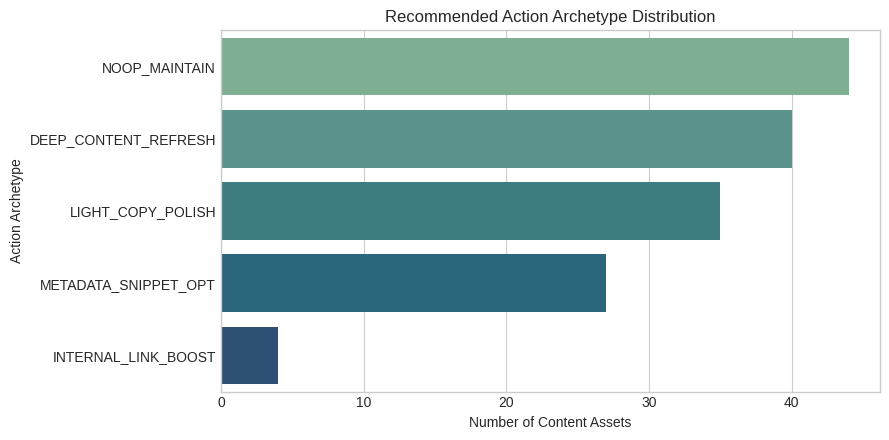

Exported Figure: ../work/figures/action_archetype_distribution.png
Exported Metrics Receipt: ../work/figures/playbook_metrics_receipt.json


In [2]:
# 1. Export Action Queue CSV (lives in work/outputs/)
queue_export_path = '../work/outputs/ranked_action_queue.csv'
ranked_queue.to_csv(queue_export_path, index=False)
print(f"Exported Action Queue: {queue_export_path}")

# 2. Generate and Export Summary Figure (lives in work/figures/)
plt.figure(figsize=(9, 4.5))
action_counts = ranked_queue['action_archetype'].value_counts()
sns.barplot(
    x=action_counts.values,
    y=action_counts.index,
    hue=action_counts.index,
    palette='crest',
    legend=False
)
plt.title("Recommended Action Archetype Distribution")
plt.xlabel("Number of Content Assets")
plt.ylabel("Action Archetype")
plt.tight_layout()

figure_export_path = '../work/figures/action_archetype_distribution.png'
plt.savefig(figure_export_path, dpi=300)
plt.show()
print(f"Exported Figure: {figure_export_path}")

# 3. Export Metrics JSON Receipt (lives in work/figures/)
metrics_receipt = {
    "total_assets_evaluated": int(len(ranked_queue)),
    "actionable_queue_size": int((ranked_queue['action_archetype'] != 'NOOP_MAINTAIN').sum()),
    "archetype_breakdown": action_counts.to_dict(),
    "mean_priority_score": float(ranked_queue['priority_score'].mean()),
    "top_action_candidate": str(ranked_queue.iloc[0]['content_id']),
    "generated_timestamp": "2026-08-31"
}

metrics_export_path = '../work/figures/playbook_metrics_receipt.json'
with open(metrics_export_path, 'w') as f:
    json.dump(metrics_receipt, f, indent=2)
print(f"Exported Metrics Receipt: {metrics_export_path}")

## 6. Self-check

- [x] Defined concrete action archetypes with explicit rule-based reason codes.
- [x] Documented intended use-cases, operational constraints, and non-causal limitations.
- [x] Established human review gating criteria and a strict "No-Go" list for automated execution.
- [x] Defined monitoring thresholds ($\text{PSI}$, Brier drift) and model retrain triggers.
- [x] Exported `ranked_action_queue.csv` to `work/outputs/` and figure/metrics receipts to `work/figures/`.